# Complete EDA

In [1]:
import os, glob

# NSL-KDD
nsl_path = "/kaggle/input/datasets/hassan06/nslkdd"
print("=== NSL-KDD contents ===")
for root, dirs, files in os.walk(nsl_path):
    for f in files:
        print(os.path.join(root, f))

# Network Intrusion (CICIDS2017-like)
cic_path = "/kaggle/input/datasets/chethuhn/network-intrusion-dataset"
print("\n=== Network Intrusion contents ===")
for root, dirs, files in os.walk(cic_path):
    for f in files:
        print(os.path.join(root, f))

=== NSL-KDD contents ===
/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.arff
/kaggle/input/datasets/hassan06/nslkdd/index.html
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-2

# # Full Exploratory Data Analysis (EDA) — NSL-KDD & CICIDS2017
# **LCGA Self-Healing IDS | Addis Ababa University**
# 
# Dataset paths:
# - NSL-KDD: /kaggle/input/datasets/hassan06/nslkdd
# - CICIDS2017: /kaggle/input/datasets/chethuhn/network-intrusion-dataset

In [2]:
# ==================== SETUP ====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, PowerTransformer
from sklearn.impute import SimpleImputer
from scipy import stats
import os, glob, warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
print("Setup complete.")

Setup complete.


# ## PART A: NSL-KDD Dataset

In [3]:
# ==================== A.1 LOAD NSL-KDD ====================

NSL_PATH = "/kaggle/input/datasets/hassan06/nslkdd"

# Column names (NSL-KDD has NO header)
COLUMNS_NSL = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

# Use root-level .txt files (not the nsl-kdd/ subfolder duplicates)
train_path = os.path.join(NSL_PATH, "KDDTrain+.txt")
test_path  = os.path.join(NSL_PATH, "KDDTest+.txt")

df_nsl_train = pd.read_csv(train_path, names=COLUMNS_NSL)
df_nsl_test  = pd.read_csv(test_path,  names=COLUMNS_NSL)

print(f"Train shape: {df_nsl_train.shape}")
print(f"Test shape:  {df_nsl_test.shape}")

# Combine for EDA
df_nsl = pd.concat([df_nsl_train, df_nsl_test], ignore_index=True)
df_nsl.drop(columns=["difficulty"], inplace=True)
print(f"Combined shape: {df_nsl.shape}")
df_nsl.head(3)

Train shape: (125973, 43)
Test shape:  (22544, 43)
Combined shape: (148517, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune


In [4]:
# ==================== A.2 BASIC CHECKING ====================
print("=== Dataset Info ===")
df_nsl.info(verbose=False)
print("\n=== Descriptive Statistics (numeric) ===")
df_nsl.describe().T.head(10)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148517 entries, 0 to 148516
Columns: 42 entries, duration to label
dtypes: float64(15), int64(23), object(4)
memory usage: 47.6+ MB

=== Descriptive Statistics (numeric) ===


,count,mean,std,min,25%,50%,75%,max
duration,148517.0,276.779305,2.460683e+03,0.0,0.0,0.0,0.0,5.771500e+04
src_bytes,148517.0,40227.949299,5.409612e+06,0.0,0.0,44.0,278.0,1.379964e+09
dst_bytes,148517.0,17088.853593,3.703525e+06,0.0,0.0,0.0,571.0,1.309937e+09
land,148517.0,0.000215,1.467714e-02,0.0,0.0,0.0,0.0,1.000000e+00
wrong_fragment,148517.0,0.020523,2.400691e-01,0.0,0.0,0.0,0.0,3.000000e+00
urgent,148517.0,0.000202,1.941708e-02,0.0,0.0,0.0,0.0,3.000000e+00
hot,148517.0,0.189379,2.013160e+00,0.0,0.0,0.0,0.0,1.010000e+02
num_failed_logins,148517.0,0.004323,7.224823e-02,0.0,0.0,0.0,0.0,5.000000e+00
logged_in,148517.0,0.402789,4.904606e-01,0.0,0.0,0.0,1.0,1.000000e+00
num_compromised,148517.0,0.255062,2.223137e+01,0.0,0.0,0.0,0.0,7.479000e+03


In [5]:
# ==================== A.3 DUPLICATES & INVALID VALUES ====================
dups = df_nsl.duplicated().sum()
print(f"Duplicate rows: {dups} ({dups/len(df_nsl)*100:.2f}%)")
df_nsl = df_nsl.drop_duplicates()

# Check for infinite values
num_cols_nsl = df_nsl.select_dtypes(include=[np.number]).columns.tolist()
inf_counts = np.isinf(df_nsl[num_cols_nsl]).sum()
inf_cols = inf_counts[inf_counts > 0]
if len(inf_cols) > 0:
    print(f"Columns with Inf values: {dict(inf_cols)}")
else:
    print("No Inf values found.")

# Check unique values in categorical columns
cat_cols_nsl = ["protocol_type", "service", "flag"]
for c in cat_cols_nsl:
    print(f"{c}: {df_nsl[c].nunique()} unique values")

Duplicate rows: 610 (0.41%)
No Inf values found.
protocol_type: 3 unique values
service: 70 unique values
flag: 11 unique values


In [6]:
# ==================== A.4 TYPE CASTING ====================
# Convert categoricals to 'category' dtype
for c in cat_cols_nsl:
    df_nsl[c] = df_nsl[c].astype("category")

# Ensure all other columns are numeric
for c in df_nsl.columns:
    if c not in cat_cols_nsl and c != "label":
        df_nsl[c] = pd.to_numeric(df_nsl[c], errors="coerce")

print("dtypes after casting:")
print(df_nsl.dtypes.value_counts())

dtypes after casting:
int64       23
float64     15
category     1
category     1
category     1
object       1
Name: count, dtype: int64


In [7]:
# ==================== A.5 ZERO-VARIANCE FEATURES ====================
variance_nsl = df_nsl[num_cols_nsl].var()
zero_var = variance_nsl[variance_nsl == 0].index.tolist()
print(f"Zero-variance features: {zero_var}")
if zero_var:
    df_nsl.drop(columns=zero_var, inplace=True)
    num_cols_nsl = [c for c in num_cols_nsl if c not in zero_var]
    print(f"Remaining numeric features: {len(num_cols_nsl)}")

Zero-variance features: ['num_outbound_cmds']
Remaining numeric features: 37


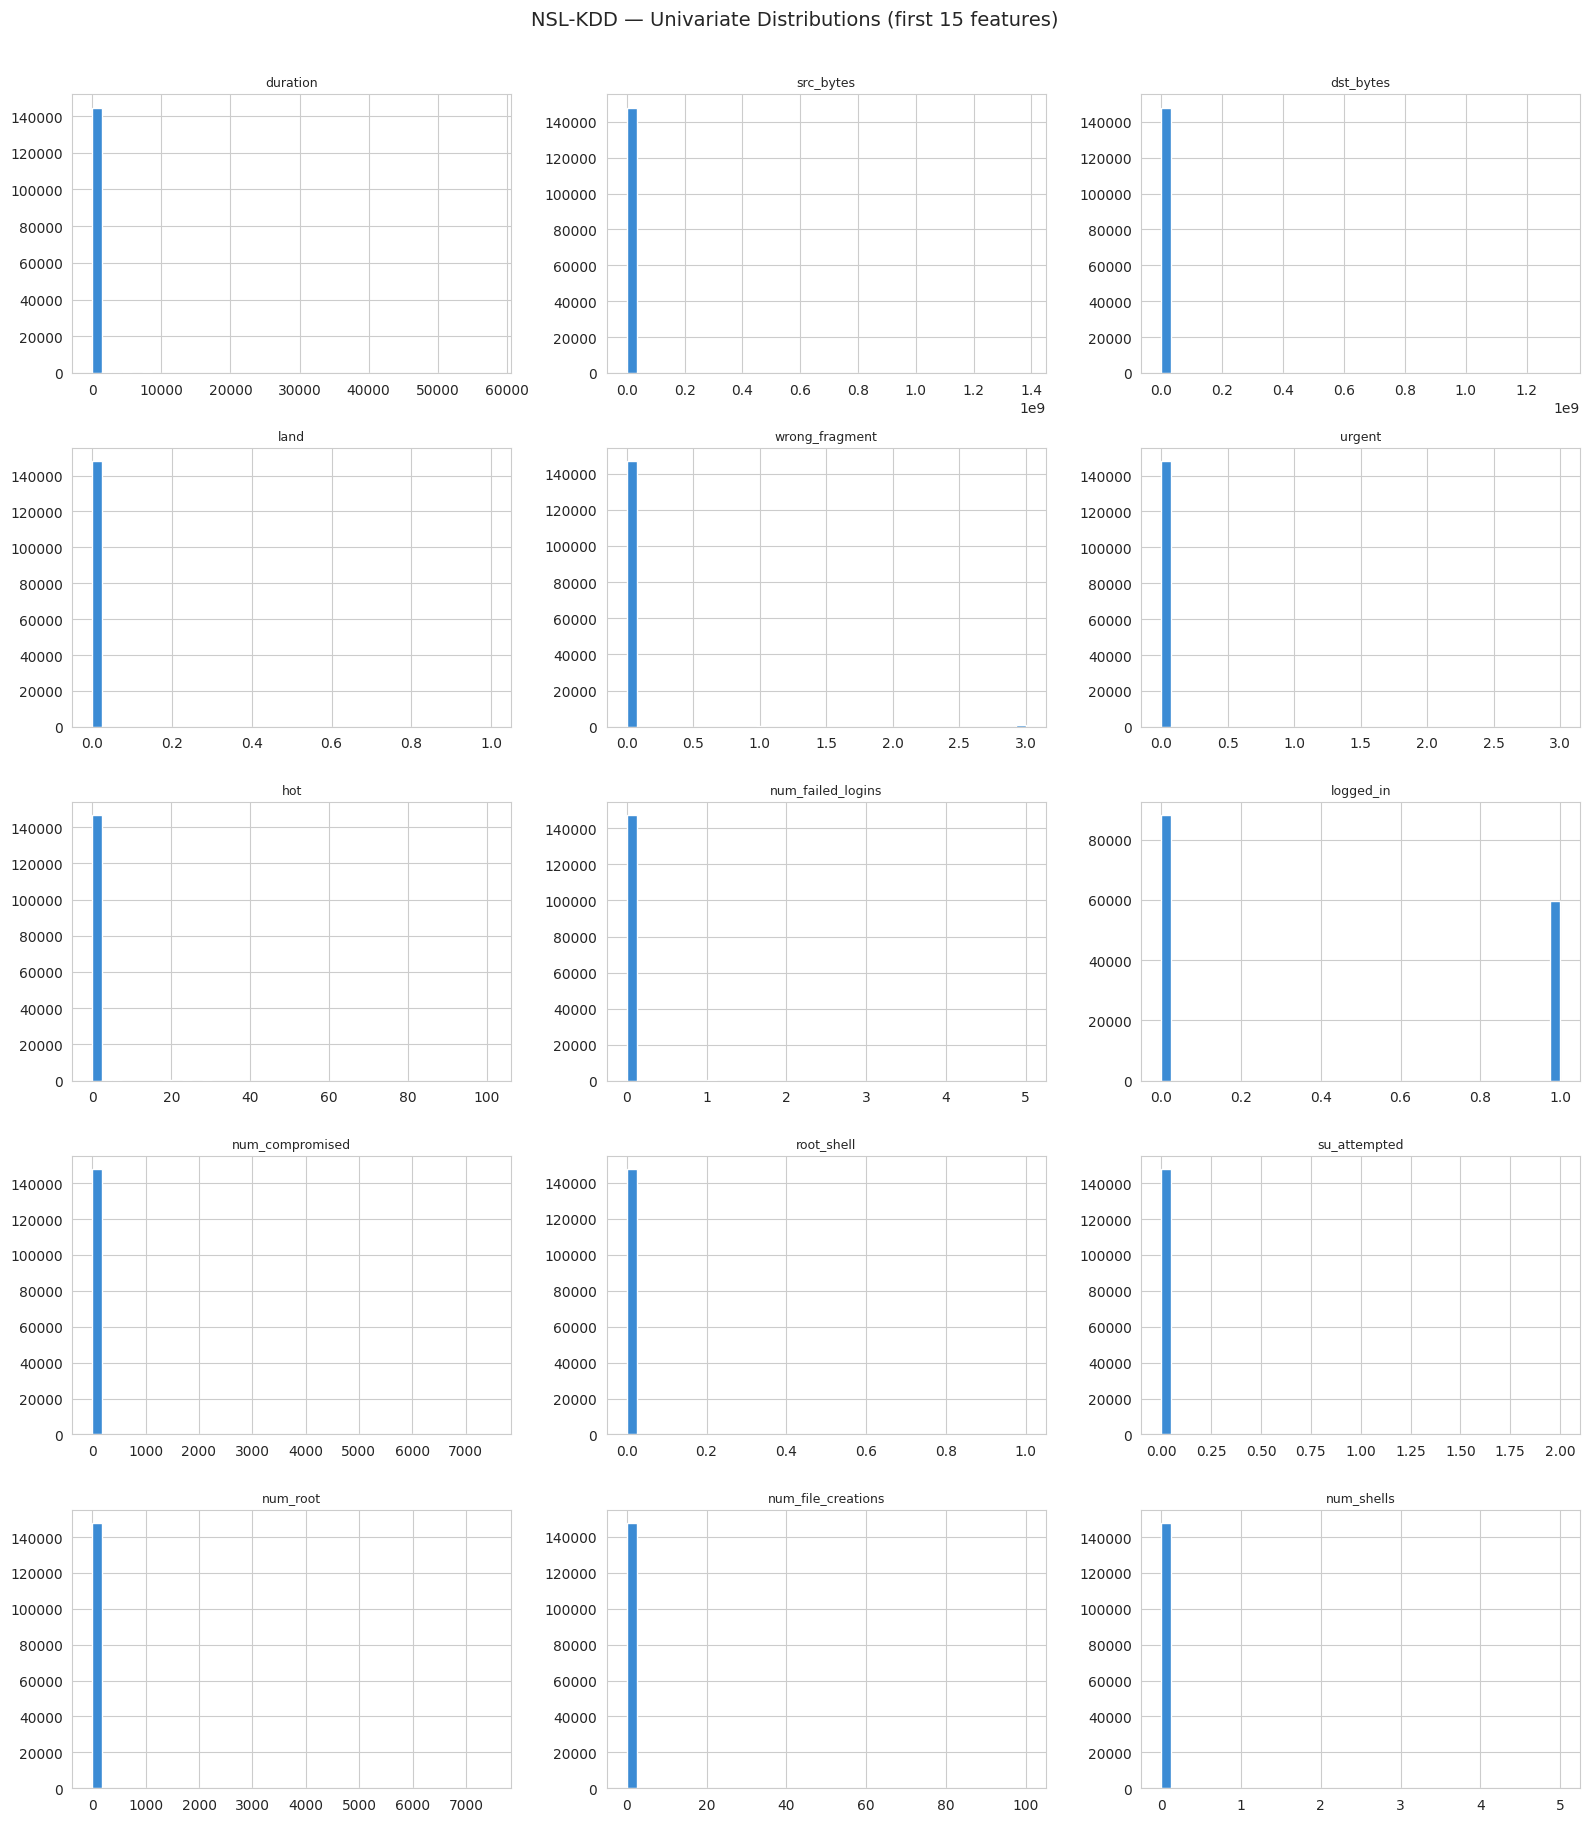

In [8]:
# ==================== A.6 UNIVARIATE ANALYSIS ====================
# Histograms for the first 15 numeric features
n_plots = min(15, len(num_cols_nsl))
fig, axes = plt.subplots(5, 3, figsize=(16, 18))
axes = axes.flatten()
for i in range(n_plots):
    df_nsl[num_cols_nsl[i]].hist(bins=40, ax=axes[i], color="#3B8BD4", edgecolor="white")
    axes[i].set_title(num_cols_nsl[i], fontsize=9)
for j in range(n_plots, len(axes)):
    axes[j].axis("off")
plt.suptitle("NSL-KDD — Univariate Distributions (first 15 features)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

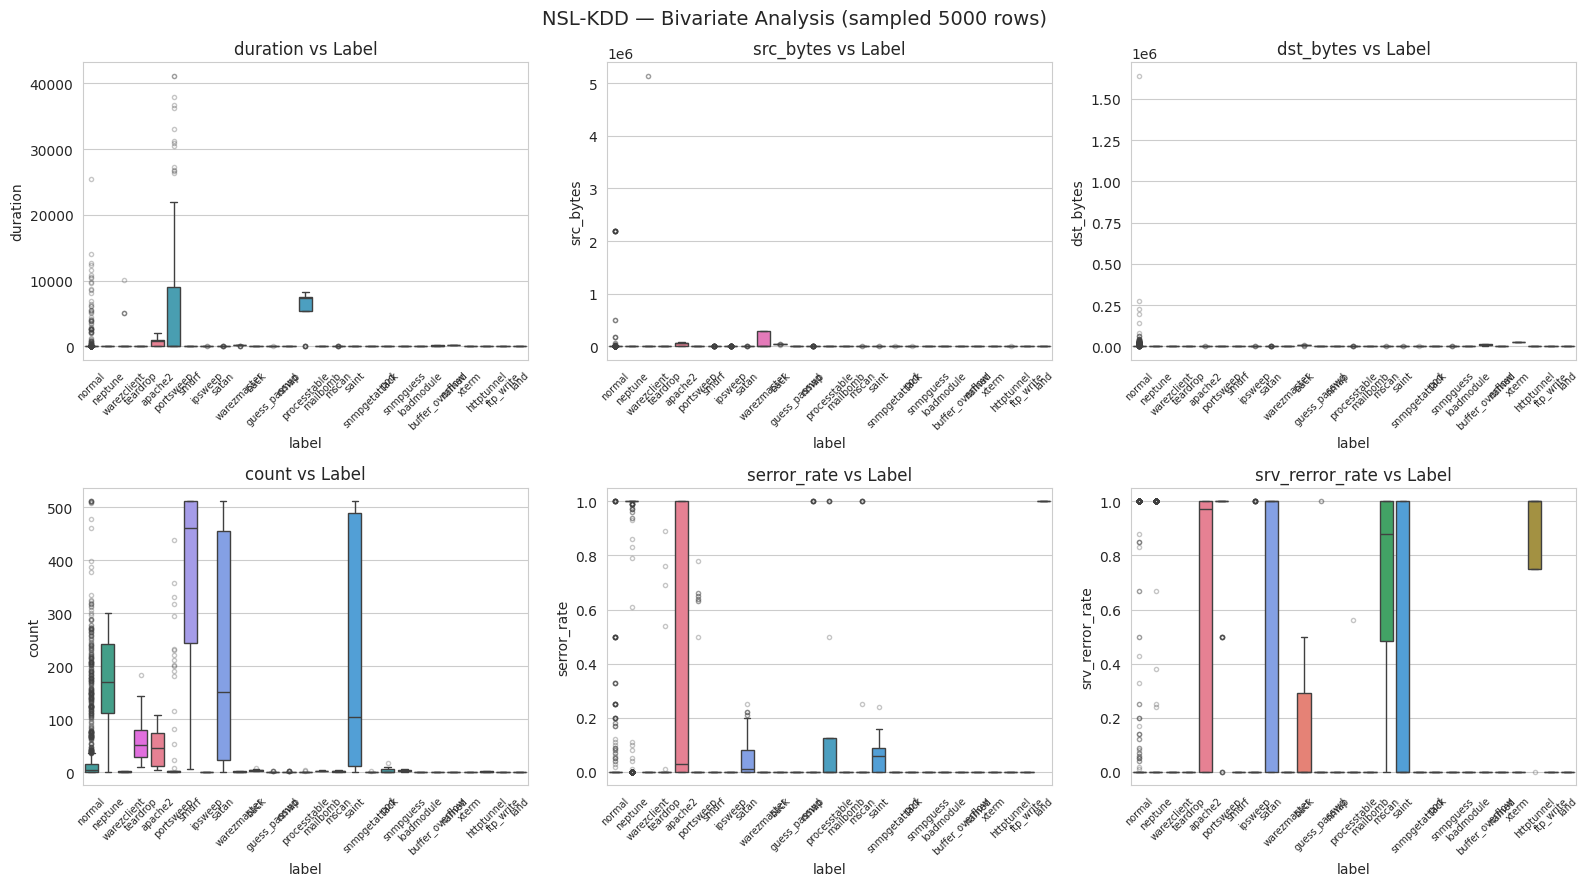

In [9]:
# %% [code]
# ==================== A.7 BIVARIATE ANALYSIS (Fixed) ====================
key_features = ["duration","src_bytes","dst_bytes","count","serror_rate","srv_rerror_rate"]
key_features = [c for c in key_features if c in num_cols_nsl]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
df_plot = df_nsl.sample(min(5000, len(df_nsl)))

# Use a generic palette for the many attack subtypes
unique_labels = sorted(df_plot["label"].unique())
palette_colors = sns.color_palette("husl", len(unique_labels))
generic_palette = dict(zip(unique_labels, palette_colors))

for i, col in enumerate(key_features):
    sns.boxplot(x="label", y=col, data=df_plot, ax=axes[i],
                palette=generic_palette, flierprops=dict(marker=".", alpha=0.3))
    axes[i].tick_params(axis="x", rotation=45, labelsize=7)
    axes[i].set_title(f"{col} vs Label")

for j in range(len(key_features), len(axes)):
    axes[j].axis("off")
plt.suptitle("NSL-KDD — Bivariate Analysis (sampled 5000 rows)", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# ==================== A.9 OUTLIER DETECTION (IQR) ====================
outlier_summary_nsl = []
for col in num_cols_nsl:
    Q1, Q3 = df_nsl[col].quantile(0.25), df_nsl[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_nsl[col] < lower) | (df_nsl[col] > upper)).sum()
    pct = n_out / len(df_nsl) * 100
    if pct > 0:
        outlier_summary_nsl.append({"feature": col, "n_outliers": n_out, "pct": pct})

outlier_df_nsl = pd.DataFrame(outlier_summary_nsl).sort_values("pct", ascending=False)
print(f"Features with outliers: {len(outlier_df_nsl)}")
display(outlier_df_nsl.head(10))

Features with outliers: 28


,feature,n_outliers,pct
22,srv_diff_host_rate,33314,22.523613
26,dst_host_rerror_rate,31827,21.518251
24,dst_host_same_src_port_rate,29612,20.020689
25,dst_host_srv_diff_host_rate,27465,18.569101
27,dst_host_srv_rerror_rate,26466,17.893676
2,dst_bytes,26073,17.627969
19,rerror_rate,21823,14.754542
20,srv_rerror_rate,21724,14.687608
1,src_bytes,16357,11.058976
18,srv_count,14814,10.015753


In [11]:
# ==================== A.10 SKEWNESS & KURTOSIS ====================
from scipy.stats import skew, kurtosis
skew_nsl = pd.DataFrame({
    "skewness": df_nsl[num_cols_nsl].apply(skew),
    "kurtosis": df_nsl[num_cols_nsl].apply(kurtosis)
})
high_skew_nsl = skew_nsl[abs(skew_nsl["skewness"]) > 1].index.tolist()
print(f"Highly skewed features (|skew| > 1): {len(high_skew_nsl)}")
display(skew_nsl.loc[high_skew_nsl].head(10))

Highly skewed features (|skew| > 1): 32


,skewness,kurtosis
duration,12.370285,173.149419
src_bytes,206.254393,46098.368200
dst_bytes,314.286339,106771.703707
land,71.394969,5095.241575
wrong_fragment,12.096896,146.241600
urgent,110.113617,13389.958219
hot,13.942152,228.553406
num_failed_logins,22.163872,738.389947
num_compromised,264.919358,86322.543146
root_shell,25.637875,655.300624


In [12]:
# ==================== A.11 TRANSFORMATIONS (Yeo-Johnson) ====================
if len(high_skew_nsl) > 0:
    pt_nsl = PowerTransformer(method="yeo-johnson")
    df_nsl[high_skew_nsl] = pt_nsl.fit_transform(df_nsl[high_skew_nsl])
    # Re-check
    new_skew = df_nsl[high_skew_nsl].apply(skew)
    print("Skewness after Yeo-Johnson:")
    print(new_skew.describe())
else:
    print("No highly skewed features to transform.")

Skewness after Yeo-Johnson:
count     32.000000
mean      15.993381
std       27.392841
min        0.071290
25%        1.071704
50%        2.015459
75%       16.251262
max      111.007132
dtype: float64


In [13]:
# %% [code]
# ==================== A.12 FEATURE ENGINEERING (Fixed) ====================
df_nsl["total_bytes"] = df_nsl["src_bytes"] + df_nsl["dst_bytes"]
df_nsl["error_rate_combined"] = df_nsl["serror_rate"] + df_nsl["srv_serror_rate"]

# is_guest_login and is_host_login are binary (0/1) as floats.
# Use addition and clip to get a proper binary flag.
df_nsl["is_guest_or_host"] = (df_nsl["is_guest_login"] + df_nsl["is_host_login"]).clip(0, 1).astype(int)

# Update the list of numeric columns
num_cols_nsl = df_nsl.select_dtypes(include=[np.number]).columns.tolist()
print(f"Engineered features added. Total numeric features: {len(num_cols_nsl)}")

Engineered features added. Total numeric features: 40


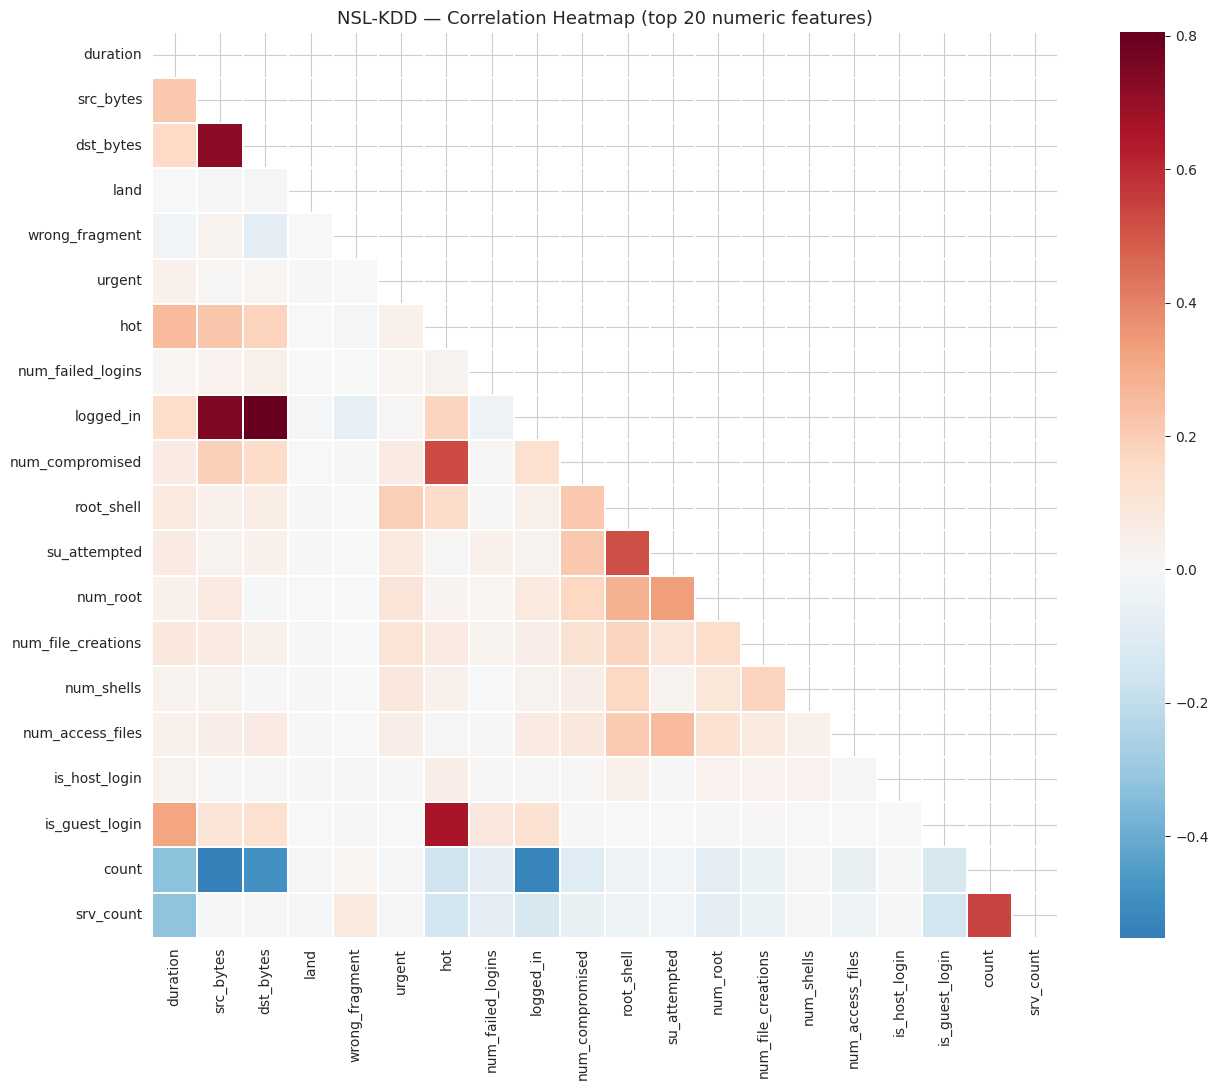

In [14]:
# ==================== A.13 CORRELATION ANALYSIS ====================
top_corr_features = num_cols_nsl[:20]  # first 20 for clarity
corr_nsl = df_nsl[top_corr_features].corr()
plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_nsl, dtype=bool))
sns.heatmap(corr_nsl, mask=mask, cmap="RdBu_r", center=0,
            annot=False, linewidths=0.3, square=True)
plt.title("NSL-KDD — Correlation Heatmap (top 20 numeric features)", fontsize=13)
plt.tight_layout()
plt.show()

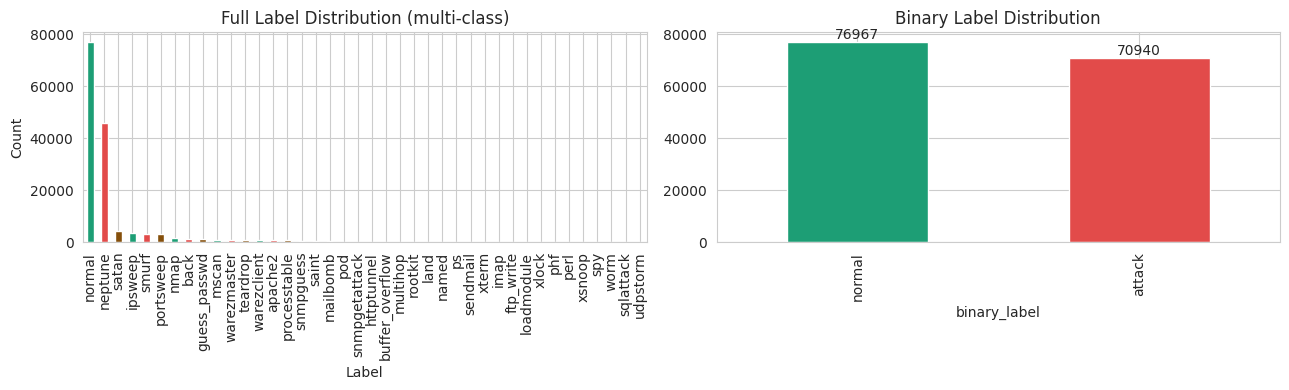

Binary distribution:
binary_label
normal    76967
attack    70940
Name: count, dtype: int64


In [15]:
# ==================== A.14 CLASS DISTRIBUTION ====================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# Original label distribution
df_nsl["label"].value_counts().plot(kind="bar", ax=axes[0],
    color=["#1D9E75","#E24B4A","#854F0B"])
axes[0].set_title("Full Label Distribution (multi-class)")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
# Binary (normal vs attack)
df_nsl["binary_label"] = df_nsl["label"].apply(lambda x: "normal" if x=="normal" else "attack")
df_nsl["binary_label"].value_counts().plot(kind="bar", ax=axes[1],
    color=["#1D9E75","#E24B4A"])
axes[1].set_title("Binary Label Distribution")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d")
plt.tight_layout()
plt.show()
print("Binary distribution:")
print(df_nsl["binary_label"].value_counts())

In [16]:
# ==================== A.15 FINAL SCALING (NSL-KDD) ====================
# Encode binary label
le_nsl = LabelEncoder()
le_nsl.fit(["normal", "attack"])
y_nsl = le_nsl.transform(df_nsl["binary_label"])

# Select final numeric features for modelling
exclude_cols = ["label", "binary_label"] + cat_cols_nsl
X_nsl_cols = [c for c in df_nsl.columns if c not in exclude_cols]
X_nsl = df_nsl[X_nsl_cols].values.astype(np.float32)

scaler_nsl = StandardScaler()
X_nsl_scaled = scaler_nsl.fit_transform(X_nsl)

print(f"Final NSL-KDD: X={X_nsl_scaled.shape}, y={y_nsl.shape}")
print(f"Class balance: {dict(zip(*np.unique(y_nsl, return_counts=True)))}")

# Save for next notebook
import joblib
os.makedirs("/kaggle/working/processed", exist_ok=True)
np.save("/kaggle/working/processed/nsl_X.npy", X_nsl_scaled)
np.save("/kaggle/working/processed/nsl_y.npy", y_nsl)
joblib.dump(scaler_nsl, "/kaggle/working/processed/nsl_scaler.pkl")
joblib.dump(le_nsl, "/kaggle/working/processed/nsl_label_enc.pkl")
joblib.dump(X_nsl_cols, "/kaggle/working/processed/nsl_feature_names.pkl")
print("NSL-KDD artifacts saved ✓")

Final NSL-KDD: X=(147907, 40), y=(147907,)
Class balance: {np.int64(0): np.int64(70940), np.int64(1): np.int64(76967)}
NSL-KDD artifacts saved ✓


# ## PART B: CICIDS2017 Dataset

In [17]:
# ==================== B.1 LOAD CICIDS2017 ====================
CIC_PATH = "/kaggle/input/datasets/chethuhn/network-intrusion-dataset"
files = sorted(glob.glob(os.path.join(CIC_PATH, "*.csv")))
print(f"Found {len(files)} CSV files:")
for f in files:
    print(f"  {os.path.basename(f)}")

dfs = []
for f in files:
    df = pd.read_csv(f, low_memory=False)
    # Strip whitespace from column names (some CICIDS files have leading/trailing spaces)
    df.columns = df.columns.str.strip()
    dfs.append(df)
df_cic = pd.concat(dfs, ignore_index=True)
print(f"\nCombined shape: {df_cic.shape}")

Found 8 CSV files:
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Friday-WorkingHours-Morning.pcap_ISCX.csv
  Monday-WorkingHours.pcap_ISCX.csv
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Tuesday-WorkingHours.pcap_ISCX.csv
  Wednesday-workingHours.pcap_ISCX.csv

Combined shape: (2830743, 79)


In [18]:
# ==================== B.2 LABEL NORMALIZATION ====================
# CICIDS2017 label column is "Label" (after stripping)
label_col = "Label"

# Check what labels exist
print("Unique raw labels:")
for lbl in sorted(df_cic[label_col].dropna().unique()):
    print(f"  '{lbl}'")

# Map to canonical names (handles both \x96 dash and regular dash variants)
LABEL_MAP_CIC = {
    "BENIGN": "BENIGN",
    "DoS Hulk": "DoS Hulk",
    "PortScan": "PortScan",
    "DDoS": "DDoS",
    "DoS GoldenEye": "DoS GoldenEye",
    "FTP-Patator": "FTP-Patator",
    "SSH-Patator": "SSH-Patator",
    "DoS slowloris": "DoS slowloris",
    "DoS Slowhttptest": "DoS Slowhttptest",
    "Bot": "Bot",
    "Web Attack \x96 Brute Force": "Web Attack Brute Force",
    "Web Attack – Brute Force": "Web Attack Brute Force",
    "Web Attack \x96 XSS": "Web Attack XSS",
    "Web Attack – XSS": "Web Attack XSS",
    "Infiltration": "Infiltration",
    "Web Attack \x96 Sql Injection": "Web Attack Sql Injection",
    "Web Attack – Sql Injection": "Web Attack Sql Injection",
    "Heartbleed": "Heartbleed",
}

df_cic[label_col] = df_cic[label_col].str.strip().map(LABEL_MAP_CIC)
unknown = df_cic[label_col].isna().sum()
print(f"Unknown labels dropped: {unknown}")
df_cic = df_cic.dropna(subset=[label_col])
print(f"After label normalization: {len(df_cic)} rows")

Unique raw labels:
  'BENIGN'
  'Bot'
  'DDoS'
  'DoS GoldenEye'
  'DoS Hulk'
  'DoS Slowhttptest'
  'DoS slowloris'
  'FTP-Patator'
  'Heartbleed'
  'Infiltration'
  'PortScan'
  'SSH-Patator'
  'Web Attack � Brute Force'
  'Web Attack � Sql Injection'
  'Web Attack � XSS'
Unknown labels dropped: 2180
After label normalization: 2828563 rows


In [19]:
# ==================== B.3 CLEANING ====================
# Drop identifier columns (not useful for ML)
drop_cols = ["Flow ID", " Source IP", " Destination IP", " Timestamp", "SimillarHTTP"]
for dc in drop_cols:
    if dc in df_cic.columns:
        df_cic.drop(columns=dc, inplace=True)

# Replace inf and drop remaining NaN
before = len(df_cic)
df_cic.replace([np.inf, -np.inf], np.nan, inplace=True)
df_cic.dropna(inplace=True)
df_cic.drop_duplicates(inplace=True)
print(f"Cleaned: {before} → {len(df_cic)} rows ({before-len(df_cic)} removed)")

Cleaned: 2828563 → 2518655 rows (309908 removed)


In [20]:
# ==================== B.4 TYPE CASTING ====================
# All columns except Label should be numeric
non_numeric = []
for col in df_cic.columns:
    if col != label_col:
        try:
            df_cic[col] = pd.to_numeric(df_cic[col], errors="raise")
        except:
            non_numeric.append(col)

if non_numeric:
    print(f"Non-numeric columns (will be dropped): {non_numeric}")
    df_cic.drop(columns=non_numeric, inplace=True)

num_cols_cic = [c for c in df_cic.columns if c != label_col]
print(f"Numeric features: {len(num_cols_cic)}")

Numeric features: 78


In [21]:
# ==================== B.5 ZERO-VARIANCE FEATURES ====================
variance_cic = df_cic[num_cols_cic].var()
zero_var_cic = variance_cic[variance_cic == 0].index.tolist()
print(f"Zero-variance features: {zero_var_cic}")
if zero_var_cic:
    df_cic.drop(columns=zero_var_cic, inplace=True)
    num_cols_cic = [c for c in num_cols_cic if c not in zero_var_cic]
    print(f"Remaining features: {len(num_cols_cic)}")

Zero-variance features: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Remaining features: 70


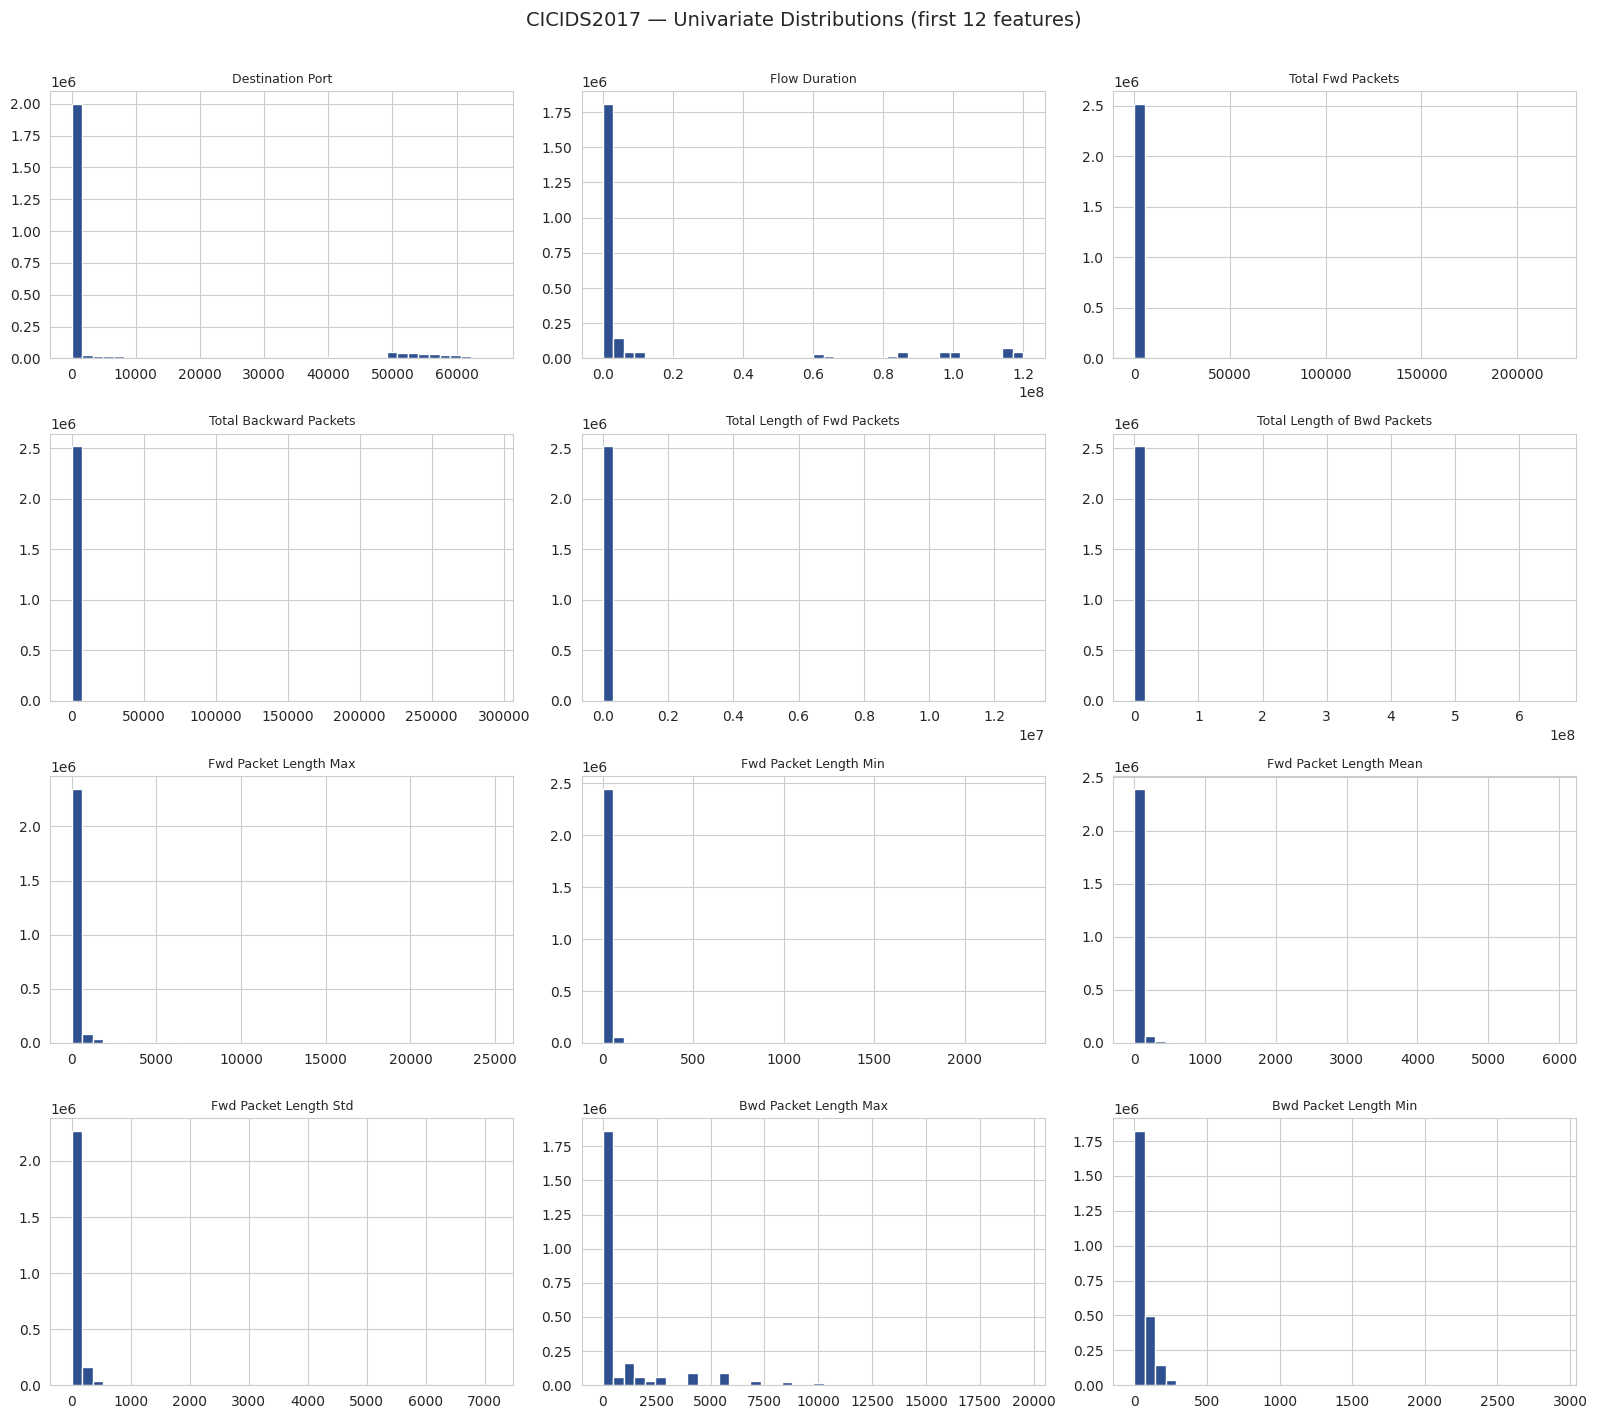

In [22]:
# ==================== B.6 UNIVARIATE ANALYSIS ====================
# First 12 numeric features
sample_cols = num_cols_cic[:12]
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(sample_cols):
    df_cic[col].hist(bins=40, ax=axes[i], color="#2E5090", edgecolor="white")
    axes[i].set_title(col[:40], fontsize=9)
for j in range(len(sample_cols), len(axes)):
    axes[j].axis("off")
plt.suptitle("CICIDS2017 — Univariate Distributions (first 12 features)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

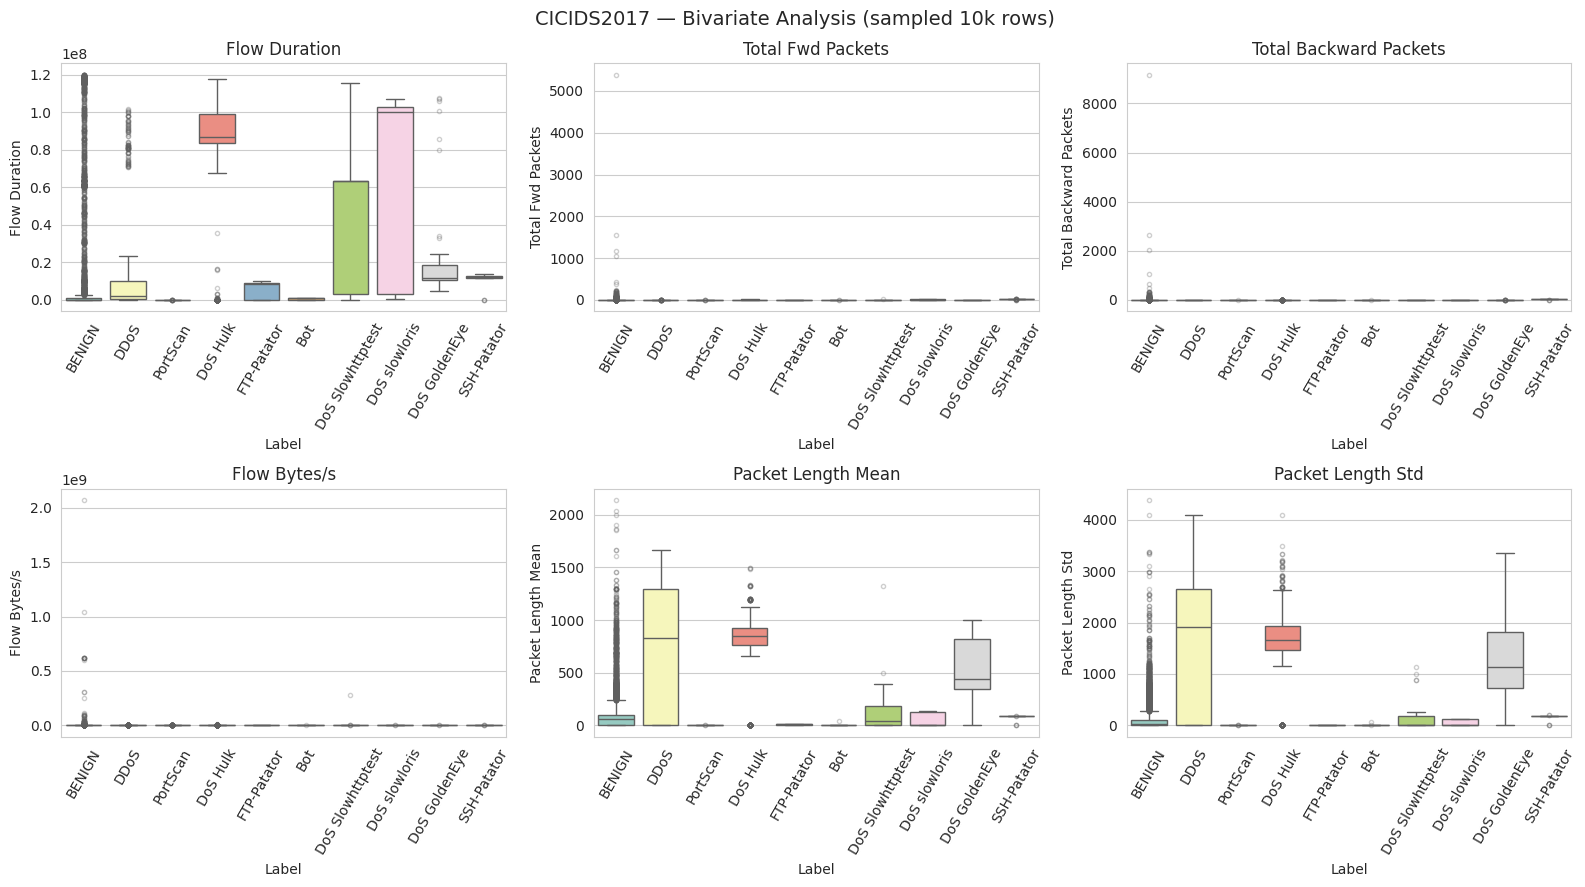

In [23]:
# ==================== B.7 BIVARIATE ANALYSIS ====================
# Boxplots: selected features grouped by Label
box_cols = ["Flow Duration", "Total Fwd Packets", "Total Backward Packets",
            "Flow Bytes/s", "Packet Length Mean", "Packet Length Std"]
box_cols = [c for c in box_cols if c in num_cols_cic]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
df_sample = df_cic.sample(min(10000, len(df_cic)), random_state=42)
for i, col in enumerate(box_cols):
    sns.boxplot(x=label_col, y=col, data=df_sample, ax=axes[i],
                palette="Set3", flierprops=dict(marker=".", alpha=0.3))
    axes[i].tick_params(axis="x", rotation=60)
    axes[i].set_title(col[:50])
for j in range(len(box_cols), len(axes)):
    axes[j].axis("off")
plt.suptitle("CICIDS2017 — Bivariate Analysis (sampled 10k rows)", fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
# ==================== B.8 MISSING VALUES ====================
missing_cic = df_cic.isnull().sum()
missing_cic = missing_cic[missing_cic > 0]
if len(missing_cic) > 0:
    print("Columns with missing values:")
    print(missing_cic)
    imputer_cic = SimpleImputer(strategy="median")
    df_cic[num_cols_cic] = imputer_cic.fit_transform(df_cic[num_cols_cic])
else:
    print("No missing values remaining.")

No missing values remaining.


In [25]:
# ==================== B.9 OUTLIER DETECTION (IQR) ====================
outlier_summary_cic = []
for col in num_cols_cic[:30]:  # limit to 30 to save time
    Q1, Q3 = df_cic[col].quantile(0.25), df_cic[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_cic[col] < lower) | (df_cic[col] > upper)).sum()
    pct = n_out / len(df_cic) * 100
    if pct > 1:
        outlier_summary_cic.append({"feature": col, "n_outliers": n_out, "pct": round(pct,1)})

outlier_df_cic = pd.DataFrame(outlier_summary_cic).sort_values("pct", ascending=False)
print(f"Features with >1% outliers (out of 30 checked): {len(outlier_df_cic)}")
display(outlier_df_cic.head(10))

Features with >1% outliers (out of 30 checked): 29


,feature,n_outliers,pct
21,Fwd IAT Std,597736,23.7
5,Total Length of Bwd Packets,575324,22.8
0,Destination Port,545620,21.7
24,Bwd IAT Total,527360,20.9
25,Bwd IAT Mean,519177,20.6
23,Fwd IAT Min,511404,20.3
27,Bwd IAT Max,508576,20.2
20,Fwd IAT Mean,506191,20.1
15,Flow IAT Mean,502998,20.0
26,Bwd IAT Std,496122,19.7


In [26]:
# ==================== B.10 SKEWNESS & KURTOSIS ====================
skew_cic = pd.DataFrame({
    "skewness": df_cic[num_cols_cic].apply(skew),
    "kurtosis": df_cic[num_cols_cic].apply(kurtosis)
})
high_skew_cic = skew_cic[abs(skew_cic["skewness"]) > 1].index.tolist()
print(f"Highly skewed features (|skew| > 1): {len(high_skew_cic)} out of {len(num_cols_cic)}")
display(skew_cic.loc[high_skew_cic].head(10))

Highly skewed features (|skew| > 1): 68 out of 70


,skewness,kurtosis
Destination Port,1.932215,1.926138
Flow Duration,1.962784,2.199475
Total Fwd Packets,230.517334,54946.160022
Total Backward Packets,230.798426,55180.363123
Total Length of Fwd Packets,760.942028,881236.273390
Total Length of Bwd Packets,230.468564,54809.600825
Fwd Packet Length Max,9.332490,122.577291
Fwd Packet Length Min,19.324241,433.635996
Fwd Packet Length Mean,8.681292,85.449182
Fwd Packet Length Std,9.960665,124.950151


In [27]:
# ==================== B.11 TRANSFORMATIONS (Yeo-Johnson) ====================
if len(high_skew_cic) > 0:
    pt_cic = PowerTransformer(method="yeo-johnson")
    df_cic[high_skew_cic] = pt_cic.fit_transform(df_cic[high_skew_cic])
    new_skew = df_cic[high_skew_cic].apply(skew)
    print("Skewness after transformation:")
    print(new_skew.describe())
else:
    print("No highly skewed features to transform.")

Skewness after transformation:
count     68.000000
mean       4.893857
std       38.171282
min     -167.549984
25%       -0.004427
50%        0.218444
75%        0.948118
max      177.426569
dtype: float64


In [28]:
# ==================== B.12 FEATURE ENGINEERING ====================
# Create a few derived features
if "Flow Bytes/s" in df_cic.columns and "Flow Packets/s" in df_cic.columns:
    df_cic["avg_packet_size"] = df_cic["Flow Bytes/s"] / (df_cic["Flow Packets/s"] + 1e-6)

if "Fwd Packet Length Max" in df_cic.columns and "Fwd Packet Length Min" in df_cic.columns:
    df_cic["fwd_pkt_range"] = df_cic["Fwd Packet Length Max"] - df_cic["Fwd Packet Length Min"]

if "Bwd Packet Length Max" in df_cic.columns and "Bwd Packet Length Min" in df_cic.columns:
    df_cic["bwd_pkt_range"] = df_cic["Bwd Packet Length Max"] - df_cic["Bwd Packet Length Min"]

num_cols_cic = [c for c in df_cic.columns if c != label_col]
print(f"Engineered features added. Total numeric: {len(num_cols_cic)}")

Engineered features added. Total numeric: 73


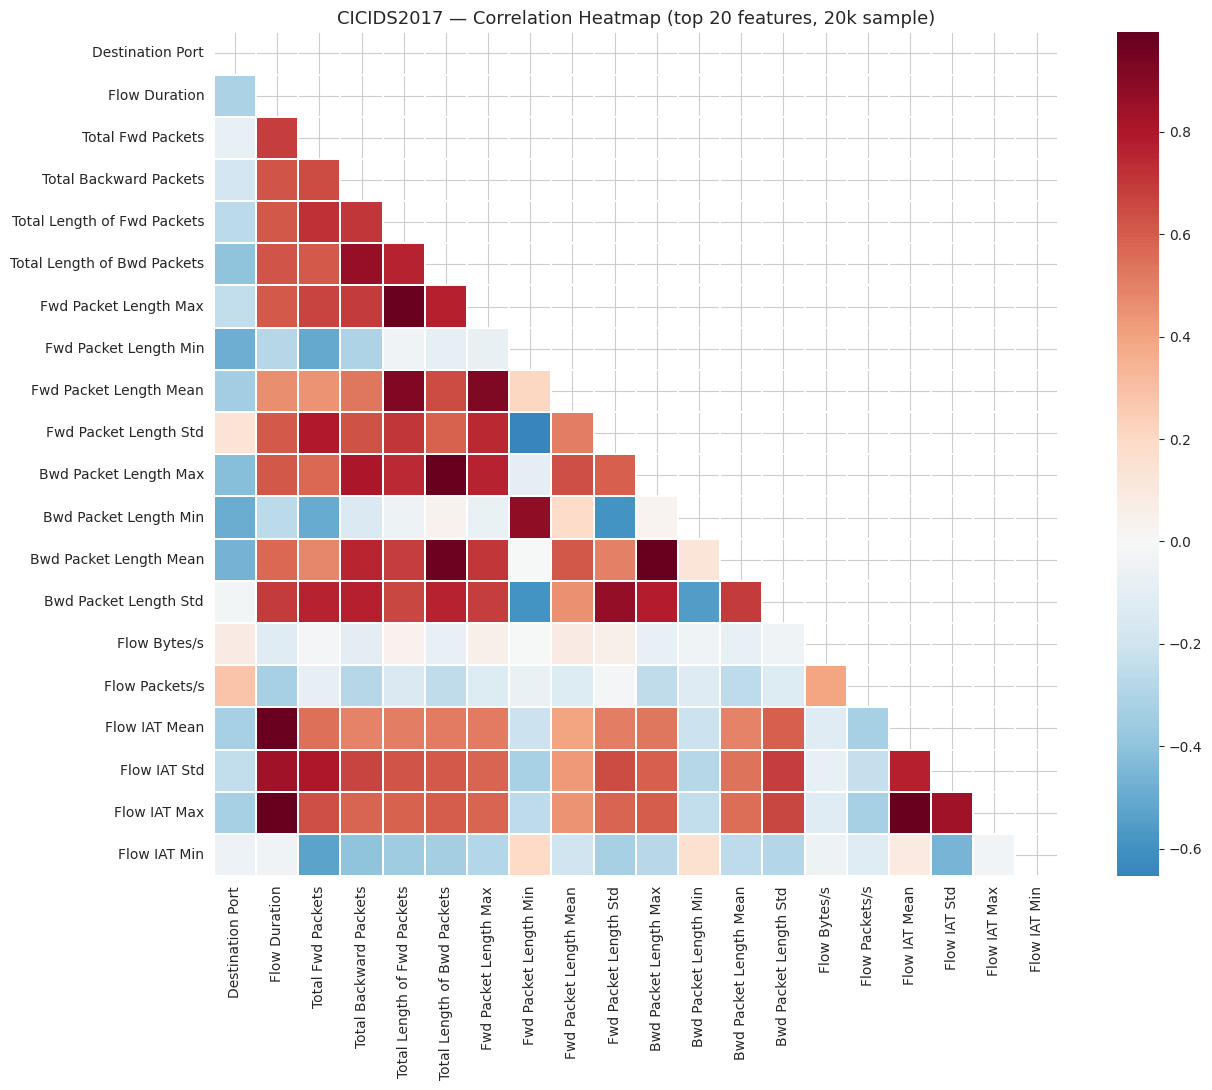

In [29]:
# ==================== B.13 CORRELATION ANALYSIS ====================
# Use a 20k sample and top 20 features for heatmap
df_corr_sample = df_cic.sample(min(20000, len(df_cic)), random_state=42)
top20 = num_cols_cic[:20]
corr_cic = df_corr_sample[top20].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_cic, dtype=bool))
sns.heatmap(corr_cic, mask=mask, cmap="RdBu_r", center=0,
            annot=False, linewidths=0.3, square=True)
plt.title("CICIDS2017 — Correlation Heatmap (top 20 features, 20k sample)", fontsize=13)
plt.tight_layout()
plt.show()

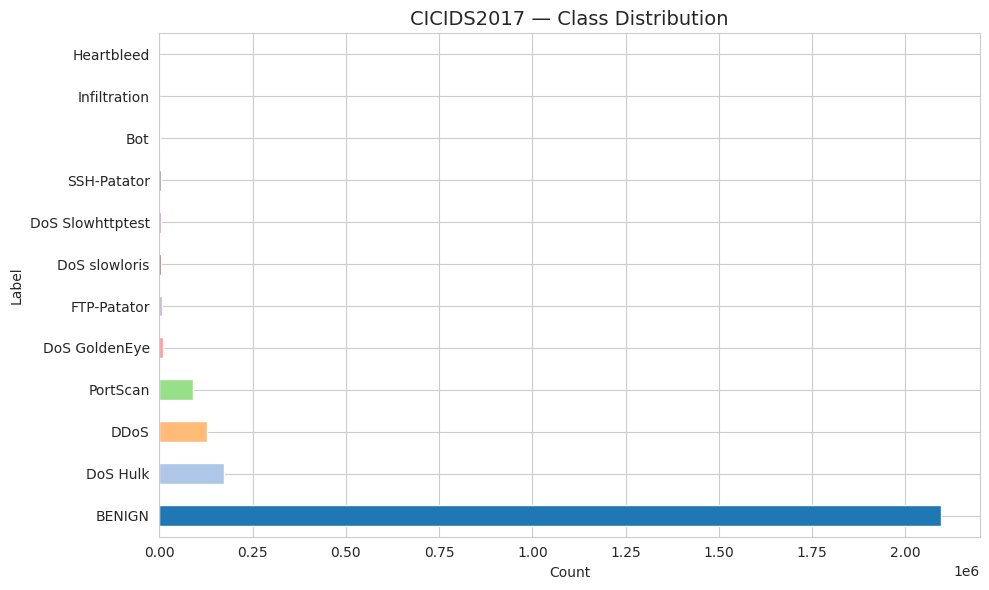


Class counts:
  BENIGN                          2,095,057  (83.18%)
  DoS Hulk                          172,846  (6.86%)
  DDoS                              128,014  (5.08%)
  PortScan                           90,694  (3.60%)
  DoS GoldenEye                      10,286  (0.41%)
  FTP-Patator                         5,931  (0.24%)
  DoS slowloris                       5,385  (0.21%)
  DoS Slowhttptest                    5,228  (0.21%)
  SSH-Patator                         3,219  (0.13%)
  Bot                                 1,948  (0.08%)
  Infiltration                           36  (0.00%)
  Heartbleed                             11  (0.00%)


In [30]:
# ==================== B.14 CLASS DISTRIBUTION ====================
plt.figure(figsize=(10, 6))
counts = df_cic[label_col].value_counts()
colors = plt.cm.tab20(np.linspace(0, 1, len(counts)))
counts.plot(kind="barh", color=colors)
plt.title("CICIDS2017 — Class Distribution", fontsize=14)
plt.xlabel("Count")
plt.tight_layout()
plt.show()
print("\nClass counts:")
for lbl, cnt in counts.items():
    print(f"  {lbl:<30} {cnt:>10,}  ({cnt/len(df_cic)*100:.2f}%)")

In [31]:
# ==================== B.15 FINAL ENCODING & SCALING (CICIDS2017) ====================
# Encode labels
le_cic = LabelEncoder()
y_cic = le_cic.fit_transform(df_cic[label_col])
class_names = list(le_cic.classes_)
print(f"Classes: {class_names}")

# Feature matrix
X_cic_cols = num_cols_cic
X_cic = df_cic[X_cic_cols].values.astype(np.float32)

# RobustScaler (better for data with many outliers)
scaler_cic = RobustScaler()
X_cic_scaled = scaler_cic.fit_transform(X_cic)

print(f"Final CICIDS2017: X={X_cic_scaled.shape}, y={y_cic.shape}")

# Save
np.save("/kaggle/working/processed/cic_X.npy", X_cic_scaled)
np.save("/kaggle/working/processed/cic_y.npy", y_cic)
joblib.dump(scaler_cic, "/kaggle/working/processed/cic_scaler.pkl")
joblib.dump(le_cic, "/kaggle/working/processed/cic_label_enc.pkl")
joblib.dump(X_cic_cols, "/kaggle/working/processed/cic_feature_names.pkl")
joblib.dump(class_names, "/kaggle/working/processed/cic_classes.pkl")
print("CICIDS2017 artifacts saved ✓")

Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator']
Final CICIDS2017: X=(2518655, 73), y=(2518655,)
CICIDS2017 artifacts saved ✓


In [32]:
# # ✅ Full EDA Complete!
# 
# **Summary:**
# - NSL-KDD: 148,517 rows → cleaned, transformed, scaled. Binary labels.
# - CICIDS2017: ~2.8M rows → cleaned, label-normalized, transformed, scaled. 15 classes.
# 
# **Saved artifacts (in /kaggle/working/processed/):**
# - `nsl_X.npy`, `nsl_y.npy`, `nsl_scaler.pkl`, `nsl_label_enc.pkl`
# - `cic_X.npy`, `cic_y.npy`, `cic_scaler.pkl`, `cic_label_enc.pkl`
# - `cic_feature_names.pkl`, `cic_classes.pkl`
# 
# Next: Proceed to **Notebook 01 — Preprocessing** (feature selection, SMOTE, sliding windows).

In [33]:
import os, numpy as np

proc_dir = "/kaggle/working/processed"
for f in sorted(os.listdir(proc_dir)):
    path = os.path.join(proc_dir, f)
    if f.endswith(".npy"):
        arr = np.load(path)
        print(f"{f}: shape={arr.shape}, dtype={arr.dtype}")
    elif f.endswith(".pkl"):
        print(f"{f}: joblib file")
    else:
        print(f"{f}: unknown")

cic_X.npy: shape=(2518655, 73), dtype=float32
cic_classes.pkl: joblib file
cic_feature_names.pkl: joblib file
cic_label_enc.pkl: joblib file
cic_scaler.pkl: joblib file
cic_y.npy: shape=(2518655,), dtype=int64
nsl_X.npy: shape=(147907, 40), dtype=float32
nsl_feature_names.pkl: joblib file
nsl_label_enc.pkl: joblib file
nsl_scaler.pkl: joblib file
nsl_y.npy: shape=(147907,), dtype=int64
